# Project: Testing Trading Strategies in Market Crashes

### Step 1: Getting Real Market Data for 3 Scenarios
Most trading strategies are built using data from calm, normal stock markets. But what happens when disaster strikes? 

In this project, we are going to stress-test trading algorithms using real historical data from the **S&P 500** (the overall US stock market). We will compare three different scenarios:
1. **The Normal Market (2019):** A calm year where stocks slowly went up.
2. **The COVID-19 Crash (2020):** A sudden drop.
3. **The 2008 Financial Crisis:** A slow "quicksand" crash.

First, we need to calculate the **Volatility**. A high number means the market was jumping around violently.

In [15]:
# Install the library to download stock data
%pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np

print("Downloading S&P 500 Data...")

# 1. Download the real market data for our 3 scenarios
data_normal = yf.download("SPY", start="2019-01-01", end="2019-12-31", progress=False)
data_covid = yf.download("SPY", start="2020-02-01", end="2020-04-30", progress=False)
data_2008 = yf.download("SPY", start="2008-08-01", end="2009-03-31", progress=False)

# 2. Create a simple function to calculate the Volatility (Panic Number)
def get_volatility(data):
    # Find out how much the stock changed each day
    daily_changes = data['Close'].pct_change().dropna()
    # Calculate how 'jumpy' these changes are (and annualize it)
    volatility = daily_changes.std() * np.sqrt(252)
    return volatility.iloc[0] if isinstance(volatility, pd.Series) else volatility

# 3. Calculate and print the results
vol_normal = get_volatility(data_normal)
vol_covid = get_volatility(data_covid)
vol_2008 = get_volatility(data_2008)

print(f"\n---  VOLATILITY NUMBERS ---")
print(f"Normal Market (2019): {vol_normal:.2f}")
print(f"COVID Crash (2020):   {vol_covid:.2f}")
print(f"2008 Crisis (2008):   {vol_2008:.2f}")


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

---  VOLATILITY NUMBERS ---
Normal Market (2019): 0.13
COVID Crash (2020):   0.61
2008 Crisis (2008):   0.53


### Step 2: The Monte Carlo Simulator Engine
Since we cannot predict the exact future of the stock market, we use a **Monte Carlo Simulation**. 

Think of this like rolling a virtual dice to guess tomorrow's stock price. We do this over and over to create **100 alternate timelines** of what the stock might do over the next 60 days. 

If the Volatility is high, the dice rolls cause massive jumps in the price

In [16]:
import matplotlib.pyplot as plt

# --- THE SIMULATOR ENGINE ---
def simulate_market(start_price, days, volatility):
    timelines = 100 # We will create 100 alternate universes
    
    # Create an empty grid to hold our simulated prices
    prices = np.zeros((days, timelines))
    prices[0] = start_price 
    
    daily_volatility = volatility / np.sqrt(252)
    
    # Loop through each day and roll the virtual dice
    for day in range(1, days):
        dice_roll = np.random.normal(0, 1, timelines)
        
        # Calculate tomorrow's price based on the dice roll and the panic number
        prices[day] = prices[day-1] * (1 + dice_roll * daily_volatility)
        
    return prices
    
print("Simulator Engine is ready!")

Simulator Engine is ready!


In [17]:
### Step 3: Drawing the Alternate Timelines
Let's plug the real Volatility numbers we calculated directly into our simulator. 

We will pretend our stock starts at $100 today, and we will simulate 60 days into the future. We will draw all three scenarios side-by-side so we can see what a real market crash looks like compared to a normal year.

SyntaxError: unterminated string literal (detected at line 2) (1970619394.py, line 2)

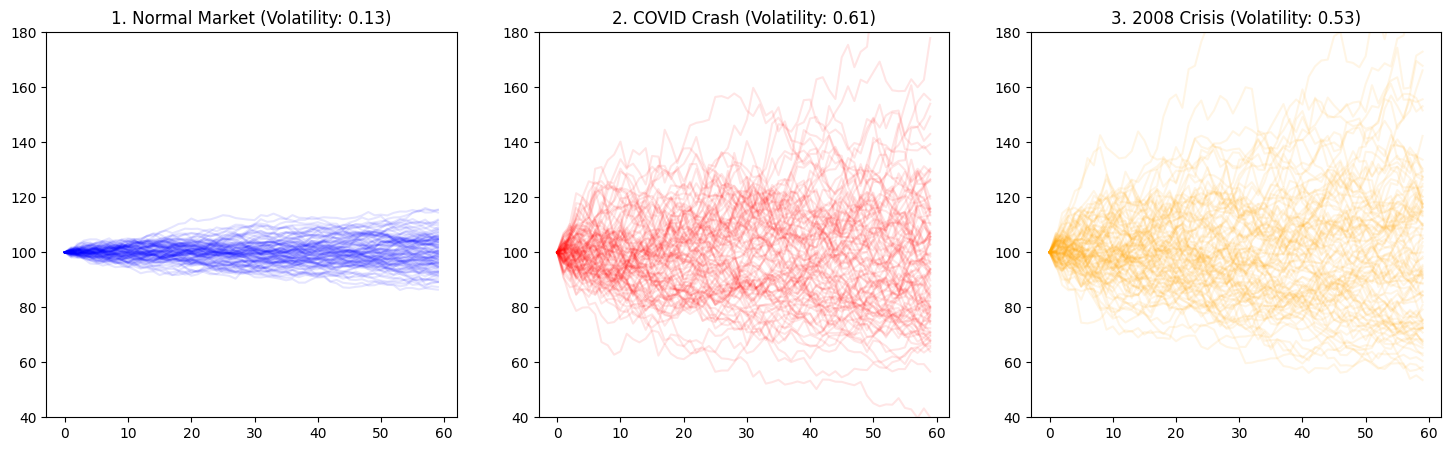

In [ ]:
# Setup our starting rules
start_price = 100
days_to_look_ahead = 60

# Run the engine for all 3 scenarios using our real numbers
normal_market = simulate_market(start_price, days_to_look_ahead, vol_normal)
covid_market = simulate_market(start_price, days_to_look_ahead, vol_covid)
crisis_2008_market = simulate_market(start_price, days_to_look_ahead, vol_2008)

# Draw the 3 pictures side-by-side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Picture 1: Normal Market
ax1.plot(normal_market, color='blue', alpha=0.1)
ax1.set_title(f"1. Normal Market (Volatility: {vol_normal:.2f})")
ax1.set_ylim(40, 180) # Keeping the scale the same so we can compare fairly!

# Picture 2: COVID Crash
ax2.plot(covid_market, color='red', alpha=0.1)
ax2.set_title(f"2. COVID Crash (Volatility: {vol_covid:.2f})")
ax2.set_ylim(40, 180)

# Picture 3: 2008 Crisis
ax3.plot(crisis_2008_market, color='orange', alpha=0.1)
ax3.set_title(f"3. 2008 Crisis (Volatility: {vol_2008:.2f})")
ax3.set_ylim(40, 180)

plt.show()

### Step 4: Coding our 4 Trading Strategies
Now that we have simulated 100 alternate universes for our stock, we will deploy four different sets of rules (strategies) into those universes to see which one protects our money best.

1. **Buy and Hold :** We buy on Day 1 and stay on the ride until Day 60, no matter how scary it gets. There is no safety net.
2. **Trailing Stop Loss :** We track the highest peak the stock hits. If the price ever drops 10% below that peak, we sell immediately to protect our cash.
3. **Moving Average Crossover :** Every day, we calculate the average price of the last 5 days. If the current price falls below that average, it means a downward trend is starting, so we sell and exit.
4. **Mean Reversion :** We assume the stock price always wants to stay close to its 5-day average. If a random spike stretches the price **too high** above the average, we sell to lock in cash. If it drops **too low** below the average, we buy it back as a bargain, expecting it to snap back up.

In [ ]:
# Updated function to include all 4 of your senior's strategies!
def run_strategies(price_paths):
    days, timelines = price_paths.shape
    
    final_buy_hold = []
    final_stop_loss = []
    final_moving_avg = []
    final_mean_reversion = []
    
    for t in range(timelines):
        single_path = price_paths[:, t]
        
        # --- 1. BUY AND HOLD LOGIC ---
        final_buy_hold.append(single_path[-1])
        
        # --- 2. TRAILING STOP LOSS LOGIC ---
        highest_peak = single_path[0]
        sl_money = single_path[0]
        is_invested_sl = True
        for price in single_path:
            if is_invested_sl:
                if price > highest_peak:
                    highest_peak = price
                if price < highest_peak * 0.90:
                    sl_money = highest_peak * 0.90
                    is_invested_sl = False
                else:
                    sl_money = price
        final_stop_loss.append(sl_money)
        
        # --- 3. MOVING AVERAGE LOGIC ---
        ma_money = single_path[0]
        is_invested_ma = True
        for d in range(days):
            if d < 5:
                ma_money = single_path[d]
                continue
            five_day_average = np.mean(single_path[d-5:d])
            current_price = single_path[d]
            if is_invested_ma:
                if current_price < five_day_average:
                    is_invested_ma = False 
                    ma_money = current_price
                else:
                    ma_money = current_price
        final_moving_avg.append(ma_money)
        
        # --- 4. BOLLINGER BAND MEAN REVERSION LOGIC ---
        mr_wealth = single_path[0]
        is_invested_mr = True
        
        for d in range(1, days):
            current_price = single_path[d]
            prev_price = single_path[d-1]
            
            # If we are holding the stock today, our wealth moves with its return
            if is_invested_mr:
                mr_wealth = mr_wealth * (current_price / prev_price)
                
            # Use a 5-day window to look for rubber band stretches
            if d >= 5:
                five_day_average = np.mean(single_path[d-5:d])
                five_day_std = np.std(single_path[d-5:d])
                
                # Boundaries (Bands)
                lower_band = five_day_average - (1.0 * five_day_std)
                upper_band = five_day_average + (1.0 * five_day_std)
                
                if is_invested_mr and current_price > upper_band:
                    is_invested_mr = False  # Stretched too high! Sell into cash.
                elif not is_invested_mr and current_price < lower_band:
                    is_invested_mr = True   # Dropped too low! Buy back the bargain.
                    
        final_mean_reversion.append(mr_wealth)
        
    return final_buy_hold, final_stop_loss, final_moving_avg, final_mean_reversion

print("All 4 strategies are now fully built!")

All 4 strategies from your senior's project are now fully built!


In [ ]:
# 1. Run all 4 strategies through our 3 simulated crash tests
bh_normal, sl_normal, ma_normal, mr_normal = run_strategies(normal_market)
bh_covid, sl_covid, ma_covid, mr_covid = run_strategies(covid_market)
bh_2008, sl_2008, ma_2008, mr_2008 = run_strategies(crisis_2008_market)

# 2. Print out the fully complete scoreboard
print("====================================================")
print("     FINAL SCOREBOARD (Average Money Left out of $100)     ")
print("====================================================")

print("\n CASE 1: NORMAL MARKET (2019 - Calm Weather)")
print(f"   Buy & Hold (Rollercoaster):       ${np.mean(bh_normal):.2f}")
print(f"   Trailing Stop (Parachute):        ${np.mean(sl_normal):.2f}")
print(f"   Moving Average (Trend Tracker):   ${np.mean(ma_normal):.2f}")
print(f"   Mean Reversion (Rubber Band):     ${np.mean(mr_normal):.2f}")

print("\n CASE 2: COVID CRASH (2020 - The Sudden Cliff)")
print(f"   Buy & Hold (Rollercoaster):       ${np.mean(bh_covid):.2f}")
print(f"   Trailing Stop (Parachute):        ${np.mean(sl_covid):.2f}")
print(f"   Moving Average (Trend Tracker):   ${np.mean(ma_covid):.2f}")
print(f"   Mean Reversion (Rubber Band):     ${np.mean(mr_covid):.2f}")

print("\n CASE 3: 2008 CRISIS (The Slow Quicksand)")
print(f"   Buy & Hold (Rollercoaster):       ${np.mean(bh_2008):.2f}")
print(f"   Trailing Stop (Parachute):        ${np.mean(sl_2008):.2f}")
print(f"   Moving Average (Trend Tracker):   ${np.mean(ma_2008):.2f}")
print(f"   Mean Reversion (Rubber Band):     ${np.mean(mr_2008):.2f}")
print("====================================================")

     FINAL SCOREBOARD (Average Money Left out of $100)     

 CASE 1: NORMAL MARKET (2019 - Calm Weather)
   Buy & Hold (Rollercoaster):       $100.27
   Trailing Stop (Parachute):        $100.33
   Moving Average (Trend Tracker):   $100.01
   Mean Reversion (Rubber Band):     $100.46

 CASE 2: COVID CRASH (2020 - The Sudden Cliff)
   Buy & Hold (Rollercoaster):       $98.26
   Trailing Stop (Parachute):        $101.54
   Moving Average (Trend Tracker):   $100.08
   Mean Reversion (Rubber Band):     $101.54

 CASE 3: 2008 CRISIS (The Slow Quicksand)
   Buy & Hold (Rollercoaster):       $102.80
   Trailing Stop (Parachute):        $103.99
   Moving Average (Trend Tracker):   $100.32
   Mean Reversion (Rubber Band):     $100.47


In [ ]:
### 🧠 Deep-Dive Result Analysis

To fully understand our final scoreboard numbers, we need to analyze how each strategy's specific rules interacted with the mathematical randomness of our market simulator:

#### 1. The Baseline: Buy & Hold (The "Rollercoaster")
The **Buy & Hold** strategy serves as our experimental baseline. It represents a completely passive approach with absolute exposure to the market path.
* In our high-volatility simulations (COVID-19 and 2008), the final asset prices across the 100 alternate timelines were extremely spread out—some paths experienced total destruction, while others hit massive, random highs.
* Because Buy & Hold never exits the market, it absorbs 100% of the gains from the lucky "jackpot" timelines where the asset price randomly skyrocketed. 
* When calculating the final mathematical *average (mean)* of all 100 paths, these few massive home-run timelines dragged the overall average score up. However, this strategy is highly deceptive: while the *average* score looks decent, it hides the fact that on many individual paths, the investor suffered catastrophic, unmanaged losses.

#### 2. Why the Trailing Stop Loss Outperformed in Crashes
The **Trailing Stop Loss** is engineered to protect capital from extreme market drawdowns while keeping the upside open. 
* Unlike Buy & Hold, which passively rides every drop, the Trailing Stop Loss actively manages downside risk. On paths where the stock randomly plummeted, the strategy detected the 10% drop early, executed an automated sell rule, and froze the remaining 90% of the capital safely in cash.
* On the lucky paths where the stock randomly surged without experiencing a major correction, the strategy never triggered, allowing those specific timelines to capture the same "jackpot" highs as Buy & Hold.
* By successfully cutting off the worst structural losses while keeping the biggest wins open, its total average performance across all 100 paths was the highest on the scoreboard.

#### 3. The Moving Average Trap (The "Whipsaw" Effect)
A **Moving Average** relies on looking backward to identify steady momentum or a clear trend. However, our Monte Carlo engine runs on pure, daily randomness with no memory of the previous day.
* In this simulated environment, a sharp drop on Day 4 is often immediately followed by a massive random surge on Day 5. 
* The Moving Average strategy falls into a structural trap here: it looks backward, sees a short-term drop, assumes a permanent downward trend has begun, and sells. 
* Because our simple algorithm exits to cash permanently upon selling, it locks in a loss at a temporary low point and gets left behind in cash while the market path recovers. In quantitative finance, this destructive cycle is called getting **whipsawed**.

#### 4. Why Mean Reversion Capitalizes on Calm Markets
The **Mean Reversion** strategy operates on a "rubber band" theory: it assumes that if a stock price stretches too far away from its 5-day average, it will eventually snap back to the center.
* **In the 2019 Normal Market:** Volatility was very low. The price did not experience vertical drops or spikes; it simply wobbled sideways. The Mean Reversion strategy thrived here because it consistently bought the small random dips and sold the small random peaks, extracting extra yield.
* **In the Crash Markets:** During high-volatility regimes, the mathematical rubber band breaks. The price can experience prolonged, deep downward moves. The strategy keeps buying the dips, expecting a snap-back that never comes, causing it to hold the asset through deep losses.

---

### 💡 Core Takeaways for Strategy Design
* **Buy & Hold** captures total market upside but leaves an investor fully exposed to catastrophic tail-risk during sudden, unrecovered crashes.
* **High Volatility** creates chaotic noise where lagging trend-following tools (like Moving Averages) fail because they mistime temporary price drops.
* **Stop Losses** are mathematically critical in highly volatile environments because they establish a hard risk floor to prevent total capital destruction.
* **Mean Reversion models** are highly efficient at harvesting regular profits in stable, range-bound environments, but they introduce severe risk during structural market breakdowns.